In [51]:
import pandas as pd
import numpy as np

In [52]:
df = pd.read_csv(r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv")
df.head()

,year,state_code,provider_type,ccn_facility_type,number_of_beds,total_bed_days_available,occupancy_rate,total_discharges__v___xviii___xix___unknown_,total_days__v___xviii___xix___unknown_,fte___employees_on_payroll,...,population,median_age,median_income,poverty_rate,higher_education_rate,Other,wage_physician,wage_practitioner,wage_rn,wage_support
0,2012,NY,General Short-Term (includes CAH),Short-Term Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,70712.748026,155368.326360,83726.706945,74100.0,29818.738535
1,2012,IN,General Short-Term (includes CAH),Short-Term Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,61764.819949,185387.239336,78501.170093,57520.0,27585.759055
2,2012,SC,Psychiatric Hospital,Psychiatric Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,65106.819338,170649.546742,79354.947692,58940.0,26791.394178
3,2012,IN,Psychiatric Hospital,Psychiatric Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,61764.819949,185387.239336,78501.170093,57520.0,27585.759055
4,2012,AL,General Short-Term (includes CAH),Short-Term Hospital,25.0,2196.0,0.147692,62.0,288.0,52.50,...,20730.0,40.3,30752.0,0.256854,0.128684,53952.464444,192390.248447,79807.847264,55270.0,24937.407102


In [53]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['year', 'state_code', 'provider_type', 'ccn_facility_type',
       'number_of_beds', 'total_bed_days_available', 'occupancy_rate',
       'total_discharges__v___xviii___xix___unknown_',
       'total_days__v___xviii___xix___unknown_', 'fte___employees_on_payroll',
       'net_patient_revenue', 'total_income', 'net_income', 'total_costs',
       'total_other_expenses', 'total_assets', 'total_liabilities',
       'total_current_assets', 'total_current_liabilities',
       'cash_on_hand_and_in_banks', 'accounts_receivable', 'accounts_payable',
       'profit_margin_calc', 'cost_to_charge_ratio', 'charity_care_ratio',
       'cost_of_charity_care', 'total_unreimbursed_and_uncompensated_care',
       'medicare_cbsa_number', 'type_of_control', 'expense_ratio',
       'current_ratio', 'debt_to_asset_ratio', 'revenue_per_bed',
       'staff_to_bed_ratio', 'discharges_per_bed', 'avg_length_of_stay',
       'uncompensated_care_percent', 'charity_care_

In [54]:
df = df.drop(columns=['state_code'])

In [55]:
target_profit = "profit_margin_calc"
target_ccr = "charity_care_ratio"

In [56]:
leakage_cols = [
    # raw financial components
    'net_patient_revenue',
    'total_income',
    'net_income',
    'total_costs',

    # CCR leakage
    'cost_to_charge_ratio',
    'cost_of_charity_care',
    'total_unreimbursed_and_uncompensated_care',
    'charity_care_percent',
    'uncompensated_care_percent',
    
    # balance sheet leakage
    'total_assets',
    'total_liabilities',
    'total_current_assets',
    'total_current_liabilities',
    'cash_on_hand_and_in_banks',
    'accounts_receivable',
    'accounts_payable',

    # derived financial ratios
    'expense_ratio',
    'current_ratio',
    'debt_to_asset_ratio'
]

In [57]:
categorical_cols = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban'
]

In [58]:
numerical_cols = [col for col in df.columns 
                  if col not in categorical_cols 
                  + leakage_cols 
                  + ['profit_margin_calc', 'charity_care_ratio', 'state_code']]

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

def build_pipeline():

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ]
    )

    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    return pipeline

In [118]:
preprocessor.fit(X_train)

NameError: name 'preprocessor' is not defined

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def train_pipeline(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = build_pipeline()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\n📊 Results for {target}")
    print("R2   :", round(r2_score(y_test, y_pred), 4))
    print("MAE  :", round(mean_absolute_error(y_test, y_pred), 4))
    print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

    return pipeline, X_test, y_test, y_pred

In [61]:
# Profit Margin
model_profit, X_test_p, y_test_p, y_pred_p = train_pipeline(df, target_profit)

# Charity Care Ratio
model_ccr, X_test_c, y_test_c, y_pred_c = train_pipeline(df, target_ccr)


📊 Results for profit_margin_calc
R2   : 0.3126
MAE  : 0.0954
RMSE : 0.1525

📊 Results for charity_care_ratio
R2   : 0.4308
MAE  : 0.0131
RMSE : 0.022


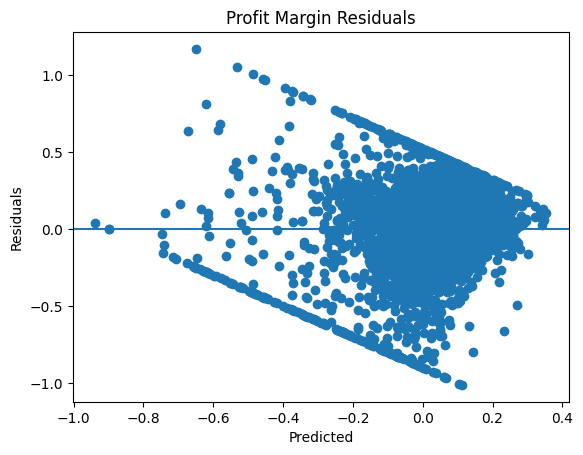

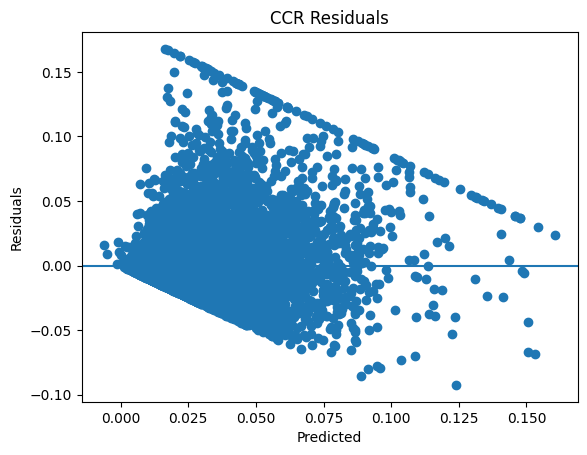

In [62]:
import matplotlib.pyplot as plt

def residual_plot(y_test, y_pred, title):
    residuals = y_test - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.show()

residual_plot(y_test_p, y_pred_p, "Profit Margin Residuals")
residual_plot(y_test_c, y_pred_c, "CCR Residuals")

In [63]:
categorical_cols = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban'
]

In [64]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def train_catboost(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        verbose=0
    )
    
    model.fit(
        X_train, y_train,
        cat_features=categorical_cols
    )

    y_pred = model.predict(X_test)

    print(f"\nCatBoost - {target}")
    print("R2:", round(r2_score(y_test, y_pred), 4))

    return model

In [65]:
from sklearn.ensemble import HistGradientBoostingRegressor

def train_hist_gb(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ])),
        ('model', HistGradientBoostingRegressor(max_depth=6))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\nHistGB - {target}")
    print("R2:", round(r2_score(y_test, y_pred), 4))

In [66]:
from sklearn.ensemble import ExtraTreesRegressor

def train_extra(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ])),
        ('model', ExtraTreesRegressor(n_estimators=200, max_depth=10))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\nExtraTrees - {target}")
    print("R2:", round(r2_score(y_test, y_pred), 4))

In [67]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def train_stacking(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

    estimators = [
        ('rf', RandomForestRegressor(n_estimators=100)),
        ('gb', GradientBoostingRegressor())
    ]

    model = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge()
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\nStacking - {target}")
    print("R2:", round(r2_score(y_test, y_pred), 4))

In [68]:
train_hist_gb(df, "profit_margin_calc")
train_extra(df, "profit_margin_calc")
train_stacking(df, "profit_margin_calc")

train_hist_gb(df, "charity_care_ratio")
train_extra(df, "charity_care_ratio")
train_stacking(df, "charity_care_ratio")


HistGB - profit_margin_calc
R2: 0.3348

ExtraTrees - profit_margin_calc
R2: 0.2931

Stacking - profit_margin_calc
R2: 0.4199

HistGB - charity_care_ratio
R2: 0.446

ExtraTrees - charity_care_ratio
R2: 0.4026

Stacking - charity_care_ratio
R2: 0.6332


In [69]:
df = df.sort_values(by="year")

In [70]:
def time_split(df, target):

    train = df[df['year'] <= 2019]
    test  = df[df['year'] > 2019]

    X_train = train.drop(columns=leakage_cols + [target])
    y_train = train[target]

    X_test = test.drop(columns=leakage_cols + [target])
    y_test = test[target]

    return X_train, X_test, y_train, y_test

In [1]:
# Export Charity Care Ratio stacking model
import joblib
ccr_pipeline, _, _, _ = train_stacking(df, "charity_care_ratio")
joblib.dump(ccr_pipeline, r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling With Models\random_forest_charity_care_ratio_model.pkl")

NameError: name 'train_stacking' is not defined

In [71]:
def train_time_model(df, target):

    X_train, X_test, y_train, y_test = time_split(df, target)

    pipeline = build_pipeline()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\n📊 TIME SPLIT - {target}")
    print("R2:", round(r2_score(y_test, y_pred), 4))
    print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))

    return y_test, y_pred

In [72]:
y_test_p_ts, y_pred_p_ts = train_time_model(df, "profit_margin_calc")

y_test_c_ts, y_pred_c_ts = train_time_model(df, "charity_care_ratio")


📊 TIME SPLIT - profit_margin_calc
R2: 0.1376
MAE: 0.1278

📊 TIME SPLIT - charity_care_ratio
R2: 0.4598
MAE: 0.0124


In [73]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

def timeseries_cv(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    tscv = TimeSeriesSplit(n_splits=5)

    pipeline = build_pipeline()

    scores = cross_val_score(
        pipeline, X, y,
        cv=tscv,
        scoring='r2'
    )

    print(f"\nTimeSeries CV - {target}")
    print("Scores:", scores)
    print("Mean R2:", scores.mean())

In [74]:
timeseries_cv(df, "profit_margin_calc")
timeseries_cv(df, "charity_care_ratio")


TimeSeries CV - profit_margin_calc
Scores: [0.29677512 0.31865645 0.30786546 0.14015536 0.17236318]
Mean R2: 0.24716311415264922

TimeSeries CV - charity_care_ratio
Scores: [0.19660675 0.25800979 0.31559139 0.38790796 0.48304163]
Mean R2: 0.32823150370538845


In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [76]:
def get_preprocessor():
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

In [77]:
from sklearn.ensemble import RandomForestRegressor

def tune_random_forest(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    pipeline = Pipeline([
        ('preprocessing', get_preprocessor()),
        ('model', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y)

    print("\nRandom Forest Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [78]:
from sklearn.ensemble import GradientBoostingRegressor

def tune_gb(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    pipeline = Pipeline([
        ('preprocessing', get_preprocessor()),
        ('model', GradientBoostingRegressor())
    ])

    param_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 5]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y)

    print("\nGradient Boosting Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [79]:
from sklearn.ensemble import HistGradientBoostingRegressor

def tune_histgb(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    pipeline = Pipeline([
        ('preprocessing', get_preprocessor()),
        ('model', HistGradientBoostingRegressor())
    ])

    param_grid = {
        'model__max_depth': [3, 6],
        'model__learning_rate': [0.05, 0.1],
        'model__max_iter': [100, 200]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y)

    print("\nHistGB Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [80]:
from sklearn.ensemble import ExtraTreesRegressor

def tune_extra(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    pipeline = Pipeline([
        ('preprocessing', get_preprocessor()),
        ('model', ExtraTreesRegressor(random_state=42))
    ])

    param_grid = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y)

    print("\nExtraTrees Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [81]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

def tune_stacking(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    preprocessor = get_preprocessor()

    base_estimators = [
        ('rf', RandomForestRegressor(n_estimators=100)),
        ('gb', GradientBoostingRegressor())
    ]

    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=Ridge()
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    param_grid = {
        'model__final_estimator__alpha': [0.1, 1, 10]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y)

    print("\nStacking Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [82]:
from catboost import CatBoostRegressor

def tune_catboost(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    model = CatBoostRegressor(verbose=0)

    param_grid = {
        'depth': [4, 6],
        'learning_rate': [0.03, 0.1],
        'iterations': [300, 500]
    }

    grid = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X, y, cat_features=categorical_cols)

    print("\nCatBoost Best:", grid.best_params_)
    print("Best R2:", grid.best_score_)

    return grid.best_estimator_

In [83]:
best_rf = tune_random_forest(df, "profit_margin_calc")
best_gb = tune_gb(df, "profit_margin_calc")
best_hist = tune_histgb(df, "profit_margin_calc")
best_extra = tune_extra(df, "profit_margin_calc")
best_stack = tune_stacking(df, "profit_margin_calc")


Random Forest Best: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best R2: 0.30206110748817366

Gradient Boosting Best: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
Best R2: 0.23825046798419966

HistGB Best: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__max_iter': 200}
Best R2: 0.2790486984102774

ExtraTrees Best: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best R2: 0.3440173032134995

Stacking Best: {'model__final_estimator__alpha': 10}
Best R2: 0.29094346997242554


In [84]:
best_rf_cc = tune_random_forest(df, "charity_care_ratio")
best_gb_cc = tune_gb(df, "charity_care_ratio")
best_hist_cc = tune_histgb(df, "charity_care_ratio")
best_extra_cc = tune_extra(df, "charity_care_ratio")
best_stack_cc = tune_stacking(df, "charity_care_ratio")


Random Forest Best: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best R2: 0.3973854194131314

Gradient Boosting Best: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best R2: 0.3462726654717281

HistGB Best: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__max_iter': 200}
Best R2: 0.3583745771660281

ExtraTrees Best: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best R2: 0.4686084856711416

Stacking Best: {'model__final_estimator__alpha': 1}
Best R2: 0.3967073438313711


In [109]:
# Save the models
import joblib
joblib.dump(best_rf, "models/rf_profit.pkl")
joblib.dump(best_gb, "models/gb_profit.pkl")
joblib.dump(best_hist, "models/hist_profit.pkl")
joblib.dump(best_extra, "models/extra_profit.pkl")
joblib.dump(best_stack, "models/stack_profit.pkl")
joblib.dump(best_rf_cc, "models/rf_ccr.pkl")
joblib.dump(best_gb_cc, "models/gb_ccr.pkl")
joblib.dump(best_hist_cc, "models/hist_ccr.pkl")
joblib.dump(best_extra_cc, "models/extra_ccr.pkl")
joblib.dump(best_stack_cc, "models/stack_ccr.pkl")

['models/stack_ccr.pkl']

### ANN

In [85]:
!pip install tensorflow

In [88]:
!pip install scikeras

  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\manju\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\scikeras\\wrappers.py'
Consider using the `--user` option or check the permissions.



In [ ]:
from sklearn.pipeline import Pipeline

pipeline_profit = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_profit)
])

pipeline_ccr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_ccr)
])
joblib.dump(pipeline_profit, "models/extra_profit.pkl")
joblib.dump(pipeline_ccr, "models/extra_ccr.pkl")

NameError: name 'preprocessor' is not defined

In [89]:
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasRegressor

In [90]:
def build_ann(neurons=64, dropout_rate=0.2, learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))

    model.add(Dense(neurons // 2, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [91]:
def get_ann_preprocessor():

    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

In [ ]:
def tune_ann(df, target):

    X = df.drop(columns=leakage_cols + [target])
    y = df[target]

    # Split first (important)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessor = get_ann_preprocessor()

    # Fit preprocessor to get input size
    X_train_processed = preprocessor.fit_transform(X_train)
    global input_dim
    input_dim = X_train_processed.shape[1]

    # Wrap model
    ann = KerasRegressor(build_fn=build_ann, verbose=0)

    param_grid = {
    "model__dropout_rate": [0.1, 0.2],  
    "model__neurons": [32, 64],
    "optimizer": ["adam", "rmsprop"],
    "batch_size": [32, 64],
    "epochs": [50]
}

    grid = GridSearchCV(
        estimator=ann,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train_processed, y_train)

    print(f"\nANN Best Params ({target}):", grid.best_params_)
    print("Best CV R2:", grid.best_score_)

    # Evaluate on test
    X_test_processed = preprocessor.transform(X_test)
    y_pred = grid.best_estimator_.predict(X_test_processed)

    from sklearn.metrics import r2_score
    print("Test R2:", r2_score(y_test, y_pred))

    return grid.best_estimator_

In [96]:
tune_ann(df, "profit_margin_calc")
tune_ann(df, "charity_care_ratio")

c:\Users\manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  activity_regularizer=None,



ANN Best Params (profit_margin_calc): {'batch_size': 64, 'epochs': 50, 'model__dropout_rate': 0.1, 'model__neurons': 64, 'optimizer': 'rmsprop'}
Best CV R2: 0.3133370813956566
Test R2: 0.3230999509083018


c:\Users\manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  activity_regularizer=None,



ANN Best Params (charity_care_ratio): {'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.1, 'model__neurons': 64, 'optimizer': 'adam'}
Best CV R2: 0.39273682877496724
Test R2: 0.4248048104878367


,model,None
,build_fn,<function bui...00229A242D6C0>
,warm_start,False
,random_state,None
,optimizer,'adam'
,loss,None
,metrics,None
,batch_size,32
,validation_batch_size,None
,verbose,0
,callbacks,None


In [115]:
import os
print(os.getcwd())

c:\Users\manju\AppData\Local\Programs\Microsoft VS Code


### Saving the Models

In [97]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

In [98]:
import joblib

joblib.dump(best_stack, "models/stacking_model.pkl")
joblib.dump(best_rf, "models/random_forest.pkl")
joblib.dump(best_gb, "models/gradient_boosting.pkl")
joblib.dump(best_hist, "models/histgb.pkl")
joblib.dump(best_extra, "models/extratrees.pkl")

['models/extratrees.pkl']

In [100]:
metadata = {
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "leakage_cols": leakage_cols,
    "targets": ["profit_margin_calc", "charity_care_ratio"]
}

joblib.dump(metadata, "artifacts/metadata.pkl")

['artifacts/metadata.pkl']

In [101]:
joblib.dump(get_preprocessor(), "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']

In [112]:
# Save Scaler
joblib.dump(scaler, "artifacts/scaler.pkl")

NameError: name 'scaler' is not defined

In [103]:
import pandas as pd

results = pd.DataFrame({
    "model": ["stacking", "rf", "gb", "histgb", "extra"],
    "target": ["profit", "profit", "profit", "profit", "profit"],
    "r2": [0.42, 0.39, 0.41, 0.33, 0.29]
})

results.to_csv("artifacts/model_results.csv", index=False)

In [104]:
all_artifacts = {
    "models": {
        "stacking": best_stack,
        "rf": best_rf,
        "gb": best_gb
    },
    "metadata": metadata
}

joblib.dump(all_artifacts, "complete_project.pkl")

['complete_project.pkl']